<a href="https://colab.research.google.com/github/andrespaul890/PCA-Y-RF-PARA-LA-IDENTIFICACI-N-DE-PATRONES-GEOQUIMICOS-EN-SEDIMENTOS-DE-LA-CORDILLERA-OCCIDENTAL/blob/main/PCA_RF_Analisis_de_datos_Geoquimicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Carga de base de datos
from google.colab import files
uploaded = files.upload()

Saving Sediment_geochemistry_final.csv to Sediment_geochemistry_final.csv


In [ ]:
df = pd.read_csv("Sediment_geochemistry_final.csv")

In [ ]:
df.head()

,MSLINK,NMUESTRA,LONGITUD,LATITUD,ELEVACION,NOMBRE,FECHA,AU,AG,CU,...,TA,TI,ZR,AS,SB,HG,PT,PD,ZONA,Fajas
0,166,206,725030.78,10030359.04,500.55,RIO GUAYLLABAMBA,17/11/1998,3.33,0.66,54.0,...,6.66,0.30,5.0,2.66,1.26,0.070,3.33,3.0,5,Cretacico_VMS_Cu-Au-Ag
1,458,553,716683.12,10046231.78,399.10,ZAPALLO,28/05/1999,5.00,0.66,153.0,...,6.66,0.32,13.0,2.66,1.26,0.026,5.00,9.0,5,Cretacico_VMS_Cu-Au-Ag
2,470,567,716909.66,10044173.49,301.34,ZAPALLO,29/05/1999,3.33,0.66,62.0,...,6.66,0.27,7.0,2.66,1.26,0.026,3.33,7.0,5,Cretacico_VMS_Cu-Au-Ag
3,472,569,717378.46,10044304.26,359.51,ZAPALLO,28/05/1999,3.33,0.66,42.0,...,6.66,0.23,8.0,2.66,1.26,0.026,3.33,3.0,5,Cretacico_VMS_Cu-Au-Ag
4,558,660,717187.61,10043974.78,358.38,ZAPALLO,28/05/1999,3.33,0.66,33.0,...,6.66,0.16,3.0,2.66,1.26,0.026,3.33,8.0,5,Cretacico_VMS_Cu-Au-Ag


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13153 entries, 0 to 13152
Data columns (total 47 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MSLINK     13153 non-null  int64  
 1   NMUESTRA   13153 non-null  int64  
 2   LONGITUD   13153 non-null  float64
 3   LATITUD    13153 non-null  float64
 4   ELEVACION  13153 non-null  float64
 5   NOMBRE     13153 non-null  object 
 6   FECHA      13153 non-null  object 
 7   AU         13153 non-null  float64
 8   AG         13153 non-null  float64
 9   CU         13153 non-null  float64
 10  PB         13153 non-null  float64
 11  ZN         13153 non-null  float64
 12  MO         13153 non-null  float64
 13  NI         13153 non-null  float64
 14  CO         13153 non-null  float64
 15  CD         13153 non-null  float64
 16  BI         13153 non-null  float64
 17  FE         13153 non-null  float64
 18  MN         13153 non-null  float64
 19  TE         13153 non-null  float64
 20  BA    

In [ ]:
#Estadística descriptiva
df.describe()

,MSLINK,NMUESTRA,LONGITUD,LATITUD,ELEVACION,AU,AG,CU,PB,ZN,...,SC,TA,TI,ZR,AS,SB,HG,PT,PD,ZONA
count,13153.000000,13153.000000,13153.000000,1.315300e+04,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,...,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000,13153.000000
mean,7358.973846,8027.662663,724977.765987,9.869419e+06,1715.860534,41.825711,0.742086,66.616970,12.817856,92.608380,...,7.148168,6.795775,0.157132,4.250167,17.475462,2.045943,0.091411,1.435320,1.475453,3.313617
std,4386.939460,4735.991404,41132.632374,1.656315e+05,973.945441,315.103586,1.592993,376.717873,113.097794,170.123356,...,5.791840,3.070099,0.104266,3.919772,171.802761,19.714395,0.983951,8.696807,3.605183,1.485620
min,1.000000,2.000000,625715.000000,9.560460e+06,76.360000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3546.000000,3928.000000,697100.000000,9.705266e+06,910.440000,3.330000,0.660000,20.000000,2.660000,59.375000,...,3.330000,6.660000,0.090000,1.000000,2.660000,1.260000,0.026000,0.000000,0.000000,2.000000
50%,7221.000000,7911.000000,724575.020000,9.894010e+06,1598.260000,3.330000,0.660000,34.000000,4.000000,77.000000,...,5.000000,6.660000,0.140000,3.000000,2.660000,1.260000,0.026000,0.000000,0.000000,4.000000
75%,11113.000000,11995.000000,751119.110000,1.002854e+07,2400.470000,10.000000,0.660000,63.000000,10.000000,98.000000,...,9.000000,6.660000,0.190000,6.000000,8.700000,1.260000,0.050000,3.330000,0.660000,5.000000
max,15175.000000,16999.000000,832652.710000,1.011049e+07,4399.900000,10000.000000,87.000000,20000.000000,8610.500000,10000.000000,...,78.000000,159.000000,0.990000,47.000000,10000.000000,2000.000000,50.000000,682.000000,127.000000,5.000000


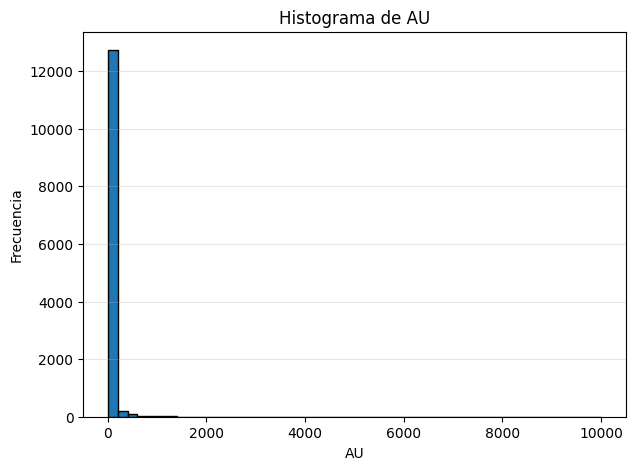

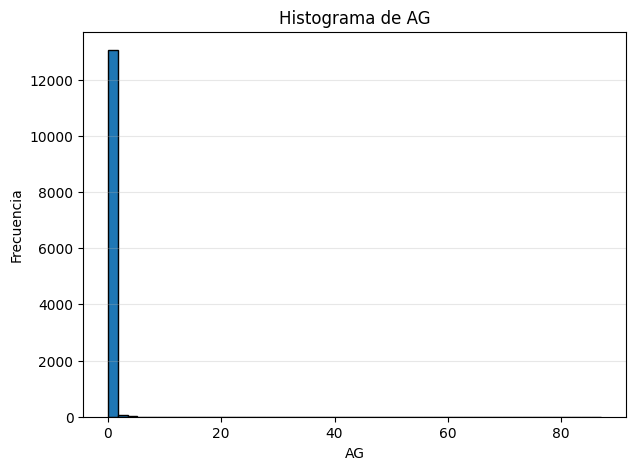

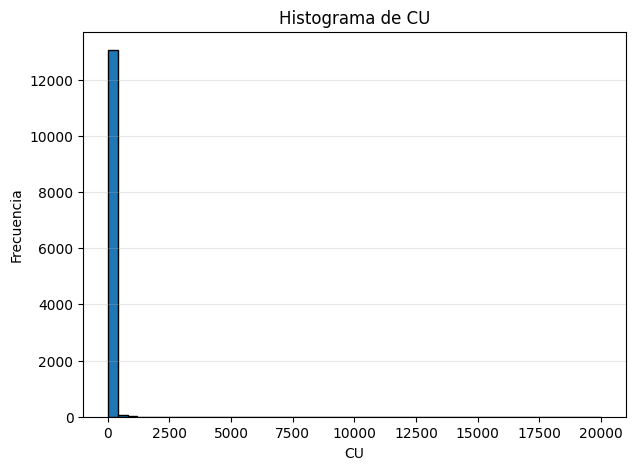

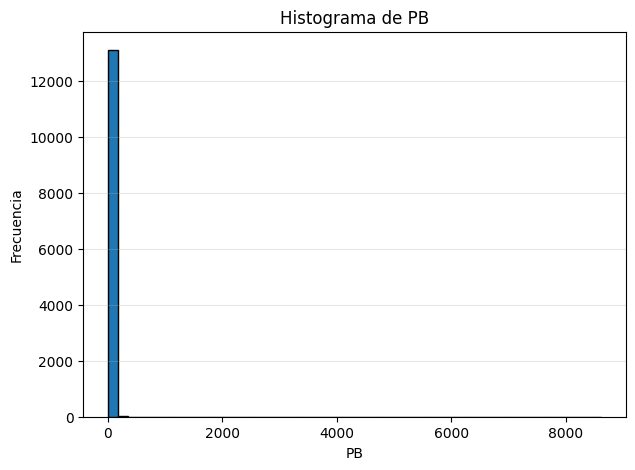

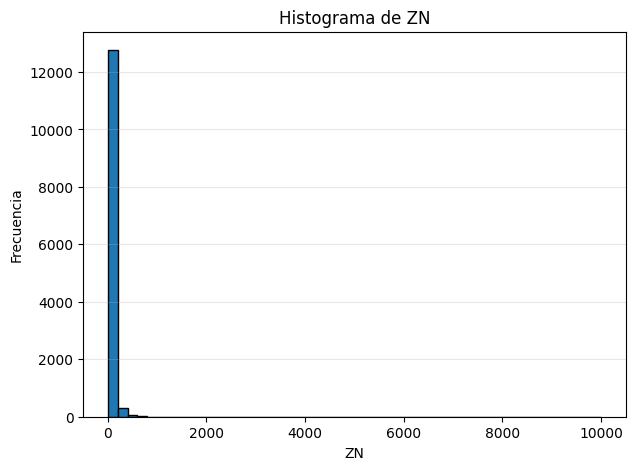

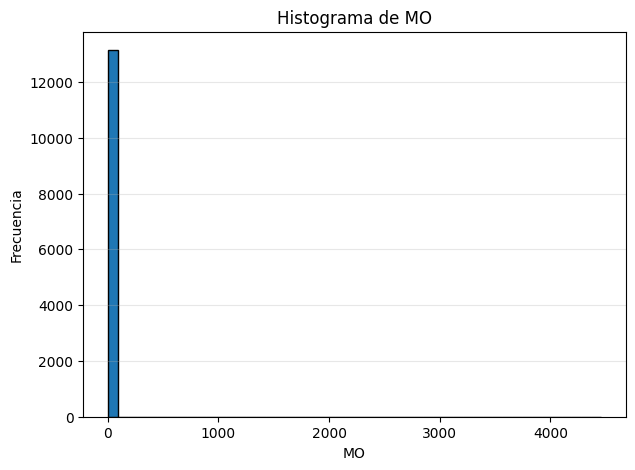

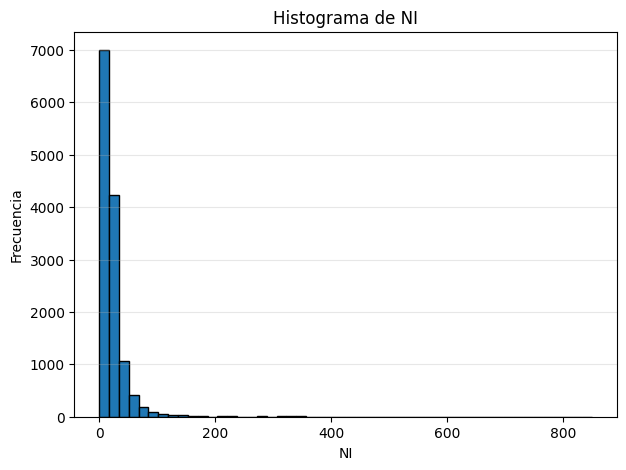

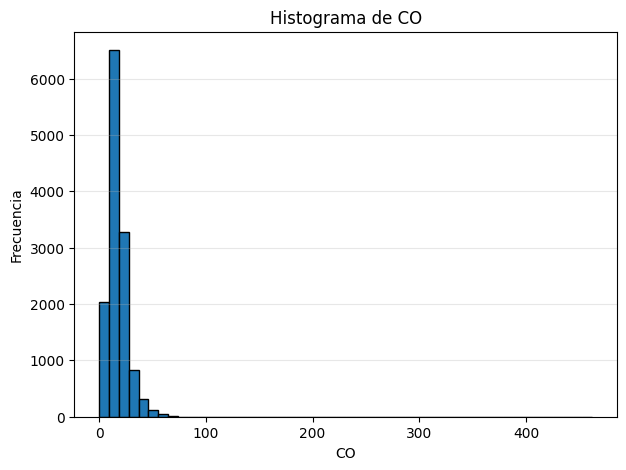

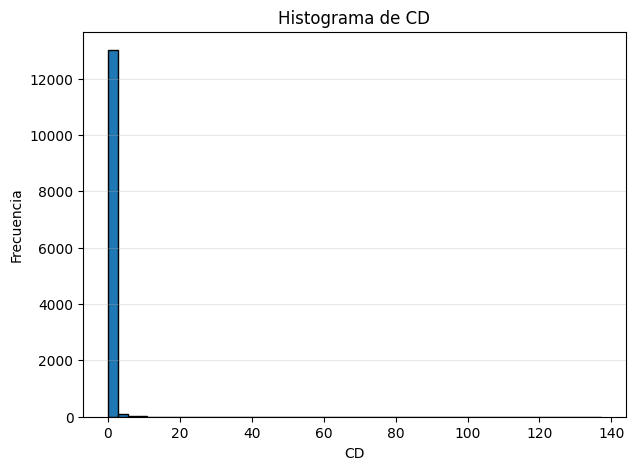

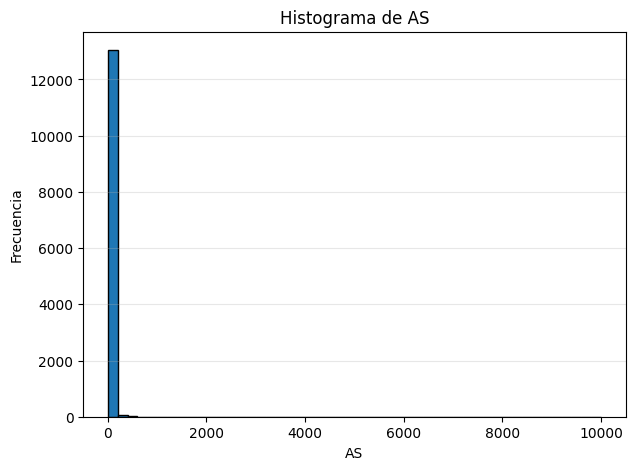

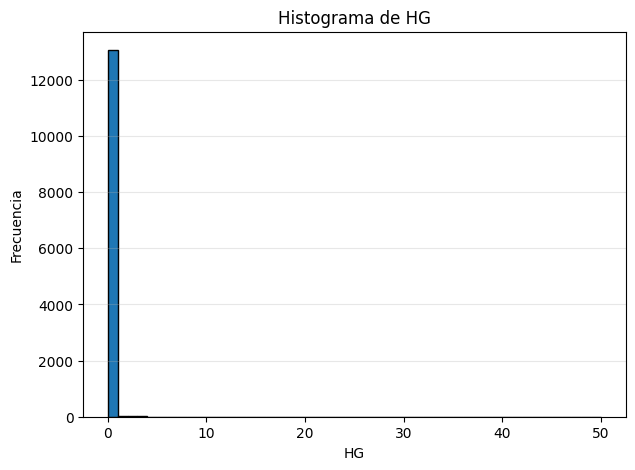

In [ ]:
# Visualización de la distribuación de algunos elementos geoquímicos

import matplotlib.pyplot as plt
import pandas as pd

elementos_hist = ["AU", "AG", "CU", "PB", "ZN", "MO", "NI", "CO", "CD", "AS", "HG"]

# Asegurar que sean numéricos
df[elementos_hist] = df[elementos_hist].apply(pd.to_numeric, errors="coerce")

for elemento in elementos_hist:
    plt.figure(figsize=(7, 5))

    plt.hist(
        df[elemento].dropna(),
        bins=50,
        edgecolor="black"
    )

    plt.xlabel(elemento)
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {elemento}")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

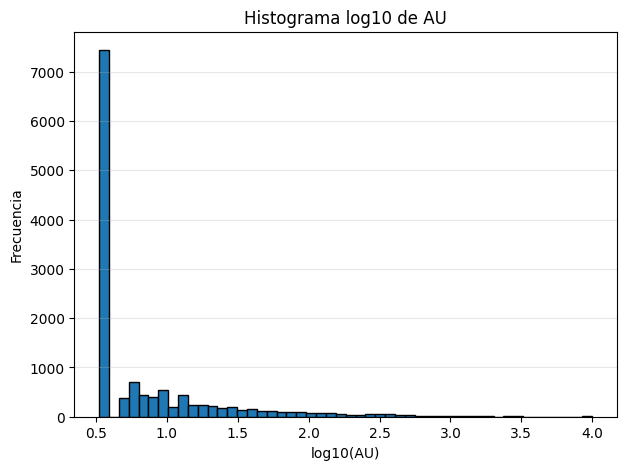

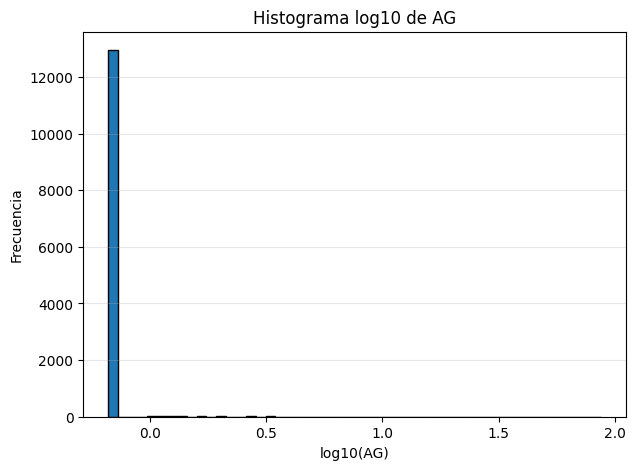

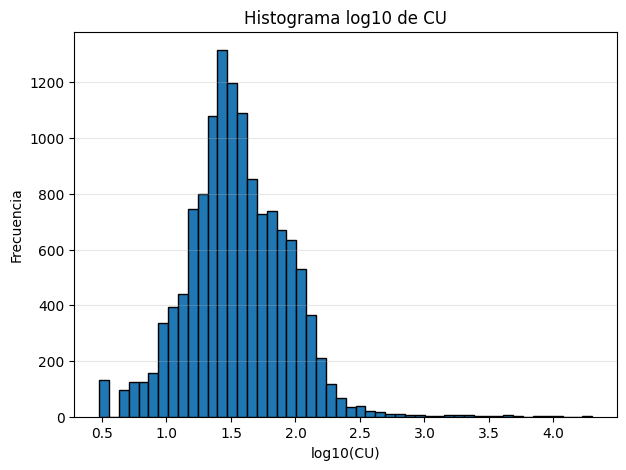

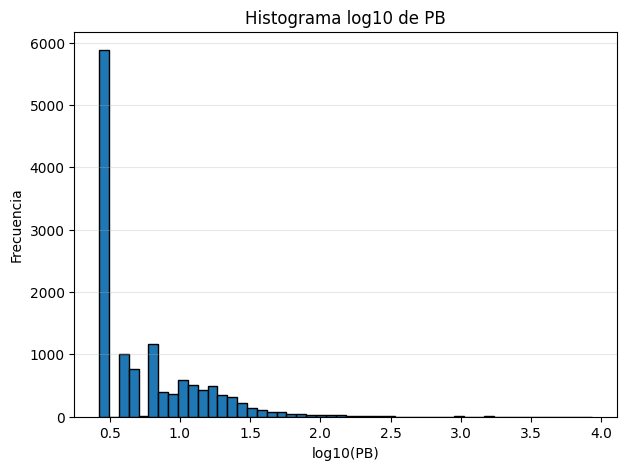

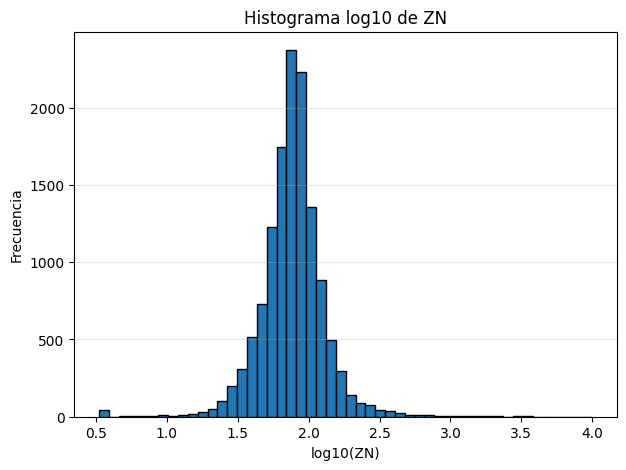

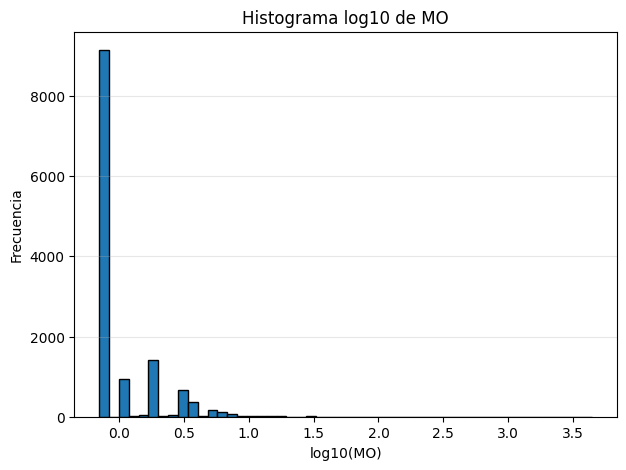

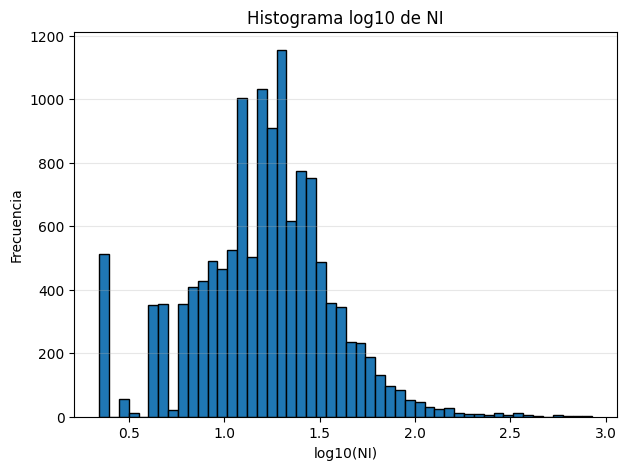

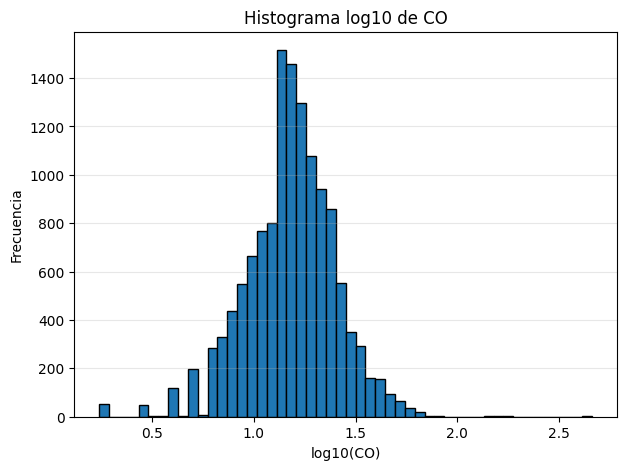

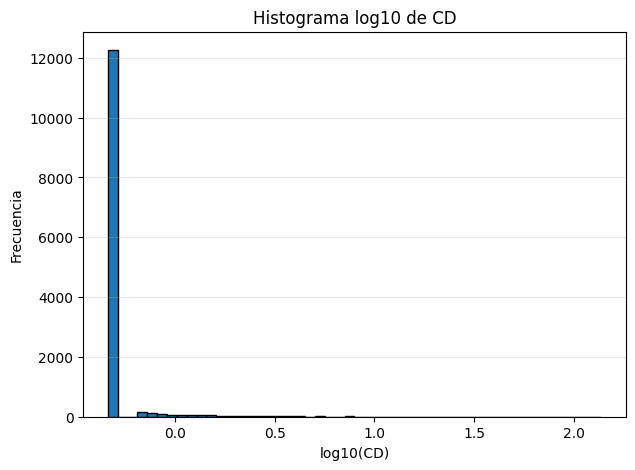

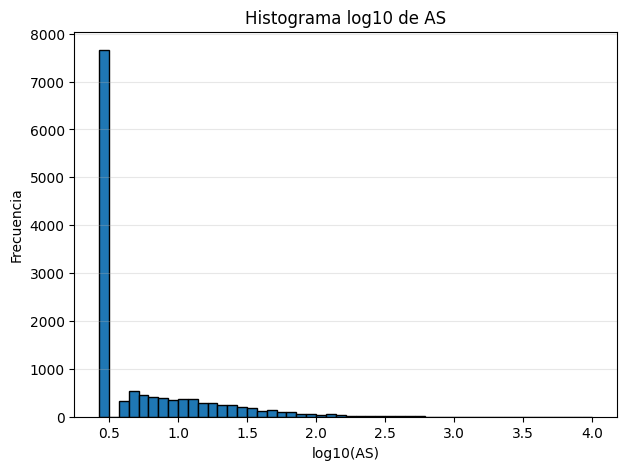

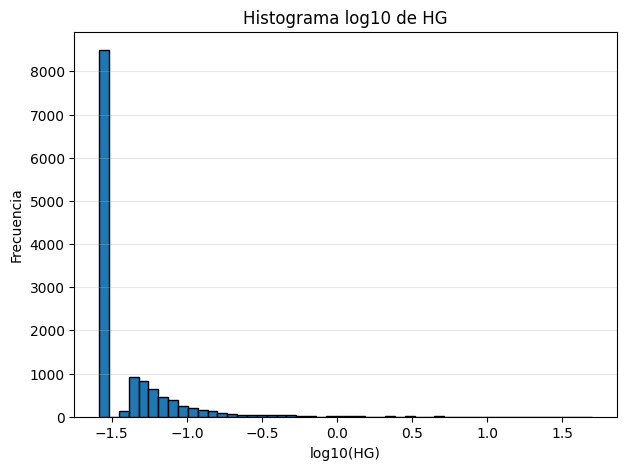

In [ ]:
# Transformación logarítmica en base 10
import numpy as np

for elemento in elementos_hist:
    datos = df[elemento].dropna()
    datos = datos[datos > 0]  # necesario para log

    plt.figure(figsize=(7, 5))

    plt.hist(
        np.log10(datos),
        bins=50,
        edgecolor="black"
    )

    plt.xlabel(f"log10({elemento})")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma log10 de {elemento}")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [ ]:
df.isnull().sum()

,0
MSLINK,0
NMUESTRA,0
LONGITUD,0
LATITUD,0
ELEVACION,0
NOMBRE,0
FECHA,0
AU,0
AG,0
CU,0


In [ ]:
df.columns

Index(['MSLINK', 'NMUESTRA', 'LONGITUD', 'LATITUD', 'ELEVACION', 'NOMBRE',
       'FECHA', 'AU', 'AG', 'CU', 'PB', 'ZN', 'MO', 'NI', 'CO', 'CD', 'BI',
       'FE', 'MN', 'TE', 'BA', 'CR', 'V', 'SN', 'W', 'LA', 'AL', 'MG', 'CA',
       'NA', 'K', 'SR', 'Y', 'GA', 'LI', 'NB', 'SC', 'TA', 'TI', 'ZR', 'AS',
       'SB', 'HG', 'PT', 'PD', 'ZONA', 'Fajas'],
      dtype='object')

In [ ]:
df.columns.tolist()

['MSLINK',
 'NMUESTRA',
 'LONGITUD',
 'LATITUD',
 'ELEVACION',
 'NOMBRE',
 'FECHA',
 'AU',
 'AG',
 'CU',
 'PB',
 'ZN',
 'MO',
 'NI',
 'CO',
 'CD',
 'BI',
 'FE',
 'MN',
 'TE',
 'BA',
 'CR',
 'V',
 'SN',
 'W',
 'LA',
 'AL',
 'MG',
 'CA',
 'NA',
 'K',
 'SR',
 'Y',
 'GA',
 'LI',
 'NB',
 'SC',
 'TA',
 'TI',
 'ZR',
 'AS',
 'SB',
 'HG',
 'PT',
 'PD',
 'ZONA',
 'Fajas']

In [ ]:
faja_col = "Fajas"

In [ ]:
geo_cols = [
    'AU','AG','CU','PB','ZN','MO','NI','CO','CD','BI',
    'FE','MN','TE','BA','CR','V','SN','W','LA','AL',
    'MG','CA','NA','K','SR','Y','GA','LI','NB','SC',
    'TA','TI','ZR','AS','SB','HG','PT','PD'
]

In [ ]:
geo_cols = [col for col in geo_cols if col in df.columns]
geo_cols

['AU',
 'AG',
 'CU',
 'PB',
 'ZN',
 'MO',
 'NI',
 'CO',
 'CD',
 'BI',
 'FE',
 'MN',
 'TE',
 'BA',
 'CR',
 'V',
 'SN',
 'W',
 'LA',
 'AL',
 'MG',
 'CA',
 'NA',
 'K',
 'SR',
 'Y',
 'GA',
 'LI',
 'NB',
 'SC',
 'TA',
 'TI',
 'ZR',
 'AS',
 'SB',
 'HG',
 'PT',
 'PD']

In [ ]:
#Limpieza de datos
df[geo_cols].eq(0).sum().sort_values(ascending=False)

,0
PD,9732
PT,9732
CU,13
PB,13
AU,13
AG,13
MO,13
ZN,13
NI,13
CO,13


In [ ]:
# eliminación de elementos con altos valores de cero
geo_cols_clean = [col for col in geo_cols if col not in ['PT', 'PD']]
geo_cols_clean

['AU',
 'AG',
 'CU',
 'PB',
 'ZN',
 'MO',
 'NI',
 'CO',
 'CD',
 'BI',
 'FE',
 'MN',
 'TE',
 'BA',
 'CR',
 'V',
 'SN',
 'W',
 'LA',
 'AL',
 'MG',
 'CA',
 'NA',
 'K',
 'SR',
 'Y',
 'GA',
 'LI',
 'NB',
 'SC',
 'TA',
 'TI',
 'ZR',
 'AS',
 'SB',
 'HG']

In [ ]:
df[geo_cols_clean] = df[geo_cols_clean].apply(pd.to_numeric, errors='coerce')

In [ ]:
!pip install scikit-bio pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
#Transformación CLR y PCA
from skbio.stats.composition import clr
from sklearn.decomposition import PCA
from pyproj import Transformer

In [ ]:
# Transforación de coordenadas para proyección espacial
transformer = Transformer.from_crs("EPSG:24877", "EPSG:4326", always_xy=True)

lon, lat = transformer.transform(
    df["LONGITUD"].values,
    df["LATITUD"].values
)

df["lon_wgs84"] = lon
df["lat_wgs84"] = lat

df[["LONGITUD", "LATITUD", "lon_wgs84", "lat_wgs84"]].head()

,LONGITUD,LATITUD,lon_wgs84,lat_wgs84
0,725030.78,10030359.04,-78.980339,0.271192
1,716683.12,10046231.78,-79.055283,0.414728
2,716909.66,10044173.49,-79.053253,0.396116
3,717378.46,10044304.26,-79.049042,0.397297
4,717187.61,10043974.78,-79.050757,0.394319


In [ ]:
#Aplicacion del PCA aplicado por Faja Metalogénica
def analizar_pca_por_faja(df, faja_valor, geo_cols, faja_col):
    df_faja = df[df[faja_col] == faja_valor].copy()

    print(f"===== FAJA: {faja_valor} =====")
    print(f"Número de muestras: {df_faja.shape[0]}")

    geo = df_faja[geo_cols].copy()

    # Eliminar columnas completamente vacías
    geo = geo.dropna(axis=1, how='all')

    # Imputar valores faltantes con la mediana
    geo = geo.fillna(geo.median())

    # Reemplazar ceros y negativos por pseudoconteo columna por columna
    geo_clean = geo.apply(
        lambda col: col.mask(col <= 0, col[col > 0].min() * 0.65)
    )

    # Eliminar columnas que todavía tengan problemas
    geo_clean = geo_clean.dropna(axis=1)

    # CLR
    geo_clr = clr(geo_clean)
    geo_clr_df = pd.DataFrame(
        geo_clr,
        columns=geo_clean.columns,
        index=df_faja.index
    )

    # PCA
    pca = PCA()
    pca_result = pca.fit_transform(geo_clr_df)

    explained = pca.explained_variance_ratio_

    print("Varianza explicada acumulada:")
    print(np.cumsum(explained)[:10])

    return df_faja, geo_clr_df, pca, pca_result

In [ ]:
df[faja_col].unique()

array(['Cretacico_VMS_Cu-Au-Ag', 'Mioceno_Porfidos-Cu-Mo-Au',
       'Oligoceno-Mioceno_Epitermales-Au-Cu',
       'Paleoceno-Eoceno_VMS_Cu-Au-Ag'], dtype=object)

In [ ]:
faja_cretacico = "Cretacico_VMS_Cu-Au-Ag"

df_cretacico, geo_clr_cretacico, pca_cretacico, pca_result_cretacico = analizar_pca_por_faja(
    df,
    faja_cretacico,
    geo_cols_clean,
    faja_col
)

===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]


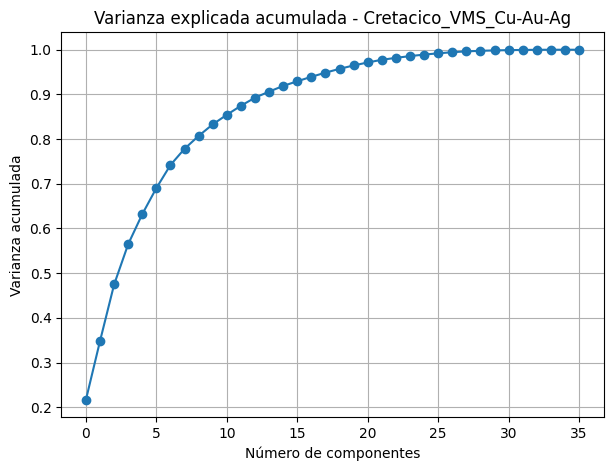

In [ ]:
explained = pca_cretacico.explained_variance_ratio_

plt.figure(figsize=(7,5))
plt.plot(np.cumsum(explained), marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title(f"Varianza explicada acumulada - {faja_cretacico}")
plt.grid()
plt.show()

In [ ]:
print(faja_cretacico)
print(df_cretacico[faja_col].unique())
print(df_cretacico.shape)

Cretacico_VMS_Cu-Au-Ag
['Cretacico_VMS_Cu-Au-Ag']
(2469, 49)


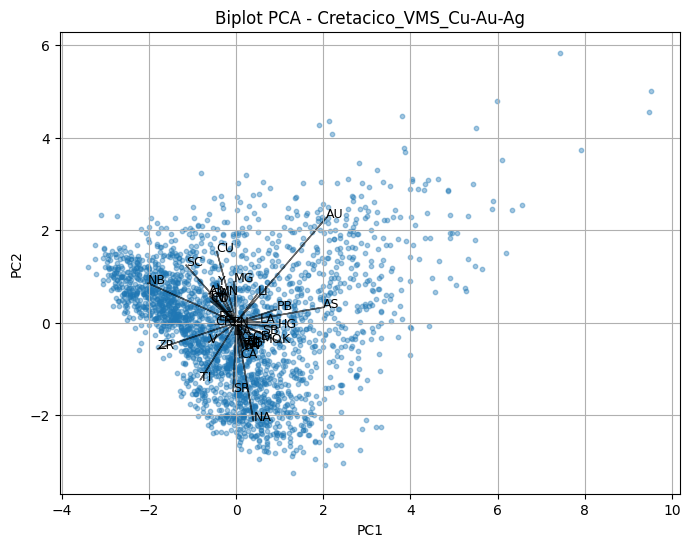

In [ ]:
loadings_cretacico = pd.DataFrame(
    pca_cretacico.components_.T,
    columns=[f"PC{i+1}" for i in range(len(geo_clr_cretacico.columns))],
    index=geo_clr_cretacico.columns
)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_result_cretacico[:, 0],
    pca_result_cretacico[:, 1],
    alpha=0.4,
    s=10
)

scale = 5

for i, var in enumerate(loadings_cretacico.index):
    plt.arrow(
        0, 0,
        loadings_cretacico.iloc[i, 0] * scale,
        loadings_cretacico.iloc[i, 1] * scale,
        alpha=0.6
    )
    plt.text(
        loadings_cretacico.iloc[i, 0] * scale,
        loadings_cretacico.iloc[i, 1] * scale,
        var,
        fontsize=9
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Biplot PCA - {faja_cretacico}")
plt.grid()
plt.show()

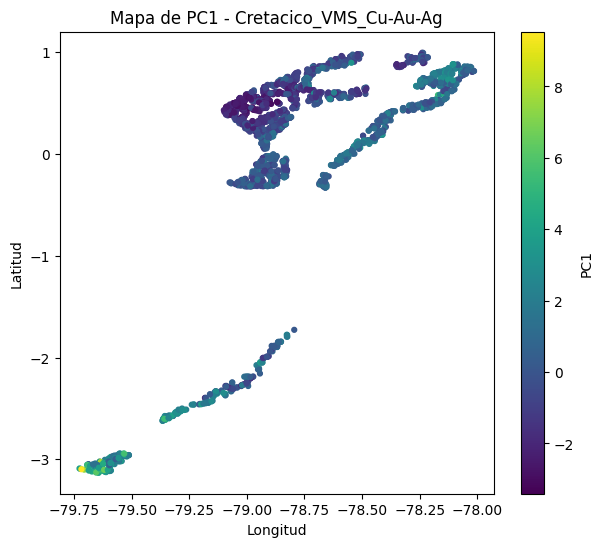

In [ ]:
# PLoteo espacial de los resultados
df_cretacico["PC1"] = pca_result_cretacico[:, 0]

plt.figure(figsize=(7,6))

sc = plt.scatter(
    df_cretacico["lon_wgs84"],
    df_cretacico["lat_wgs84"],
    c=df_cretacico["PC1"],
    s=12
)

plt.colorbar(sc, label="PC1")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Mapa de PC1 - {faja_cretacico}")
plt.show()

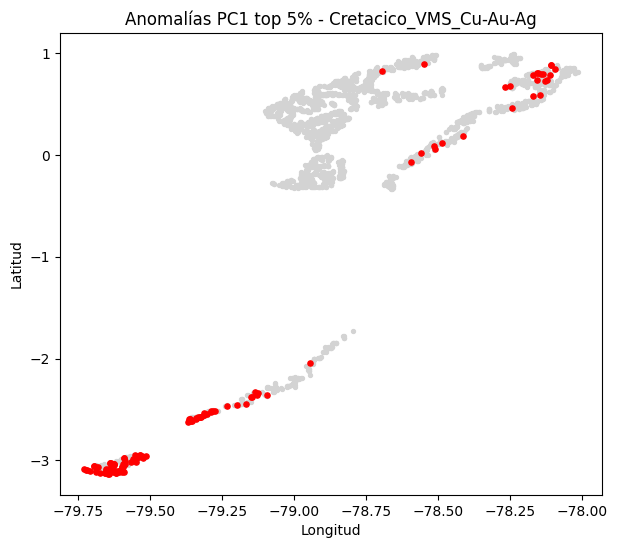

In [ ]:
threshold = df_cretacico["PC1"].quantile(0.95)
df_cretacico["PC1_anom"] = df_cretacico["PC1"] > threshold

plt.figure(figsize=(7,6))

plt.scatter(
    df_cretacico["lon_wgs84"],
    df_cretacico["lat_wgs84"],
    color="lightgray",
    s=8
)

plt.scatter(
    df_cretacico[df_cretacico["PC1_anom"]]["lon_wgs84"],
    df_cretacico[df_cretacico["PC1_anom"]]["lat_wgs84"],
    color="red",
    s=14
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Anomalías PC1 top 5% - {faja_cretacico}")
plt.show()

In [ ]:
fajas_restantes = [
    "Mioceno_Porfidos-Cu-Mo-Au",
    "Oligoceno-Mioceno_Epitermales-Au-Cu",
    "Paleoceno-Eoceno_VMS_Cu-Au-Ag"
]

===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]


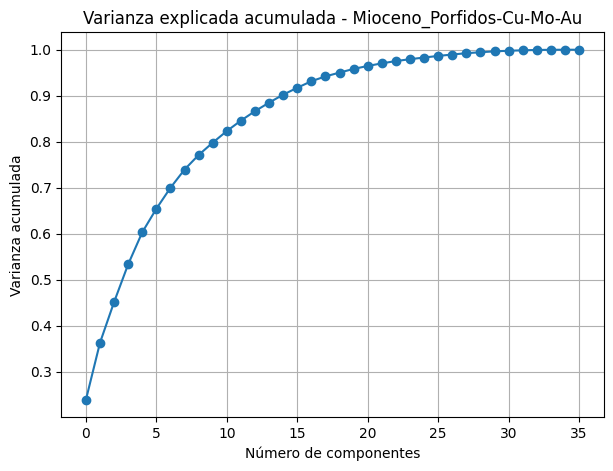

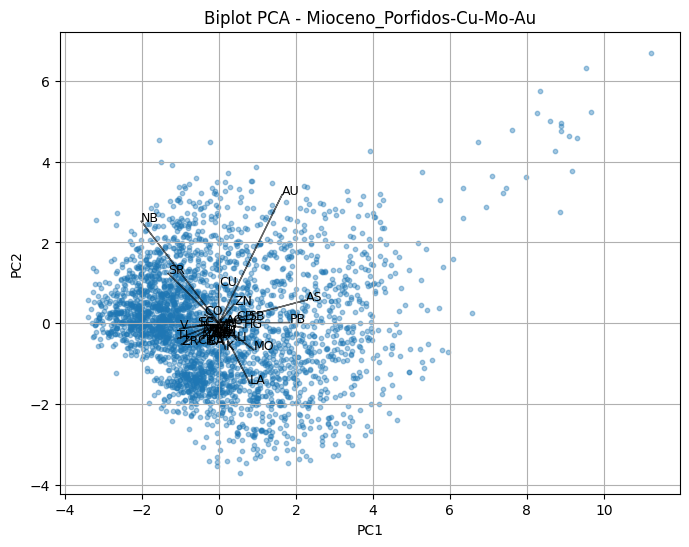

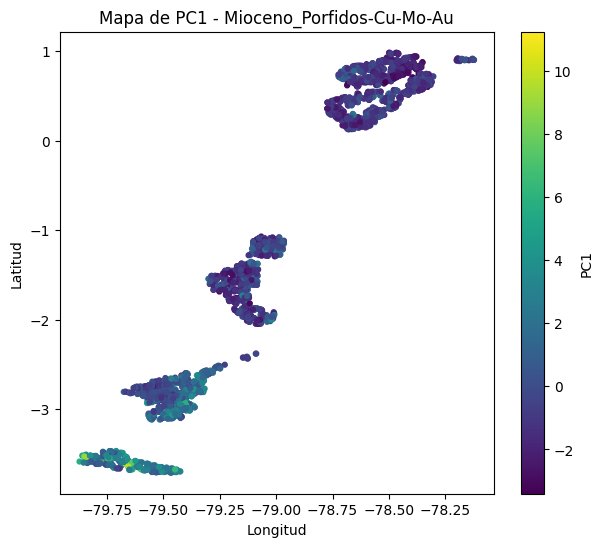

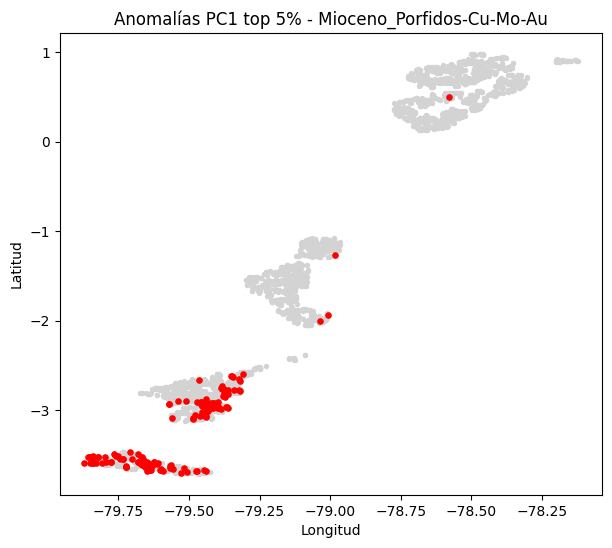

===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]


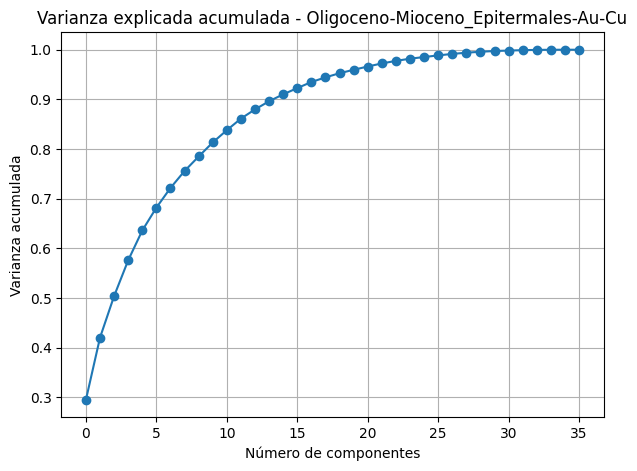

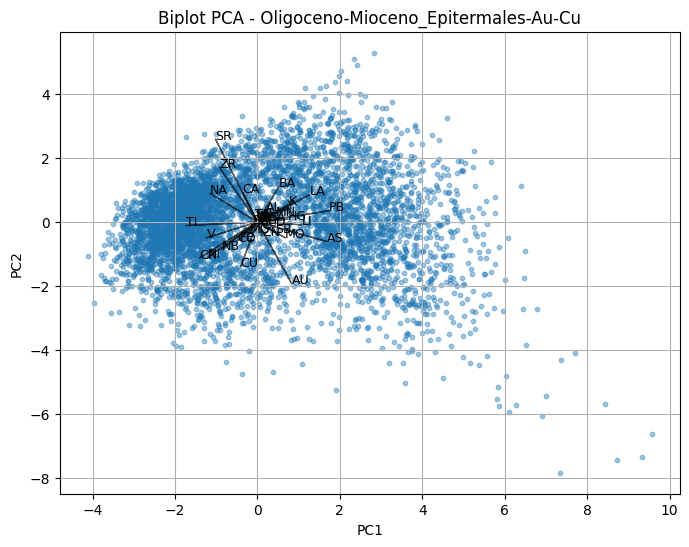

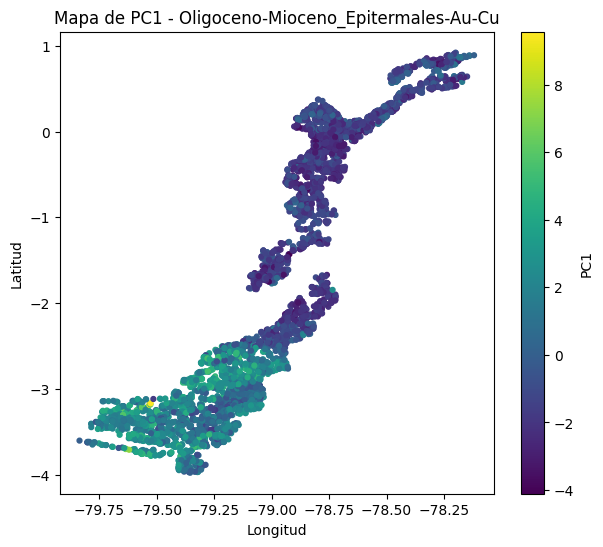

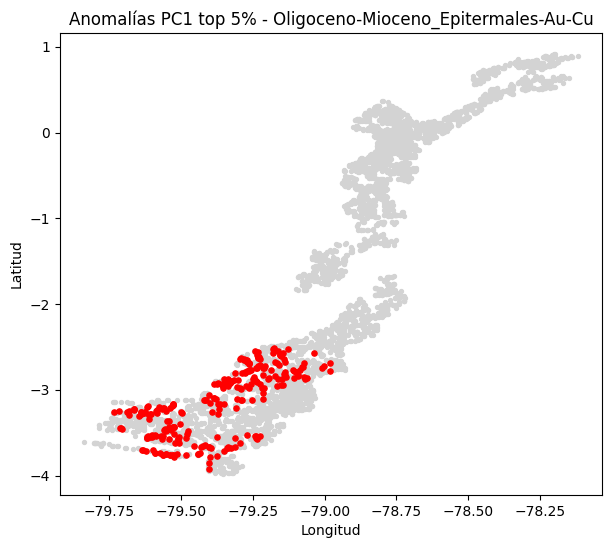

===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]


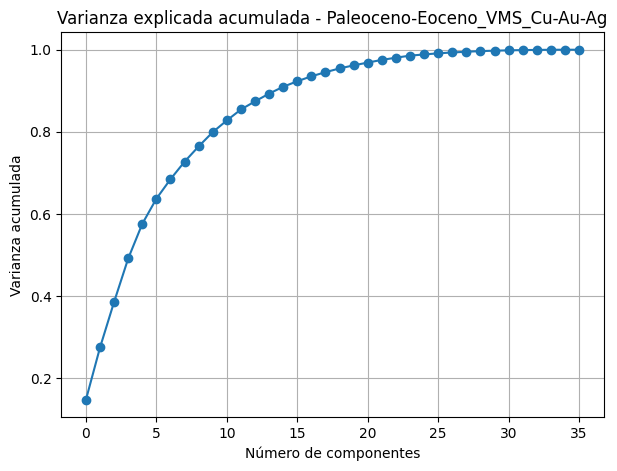

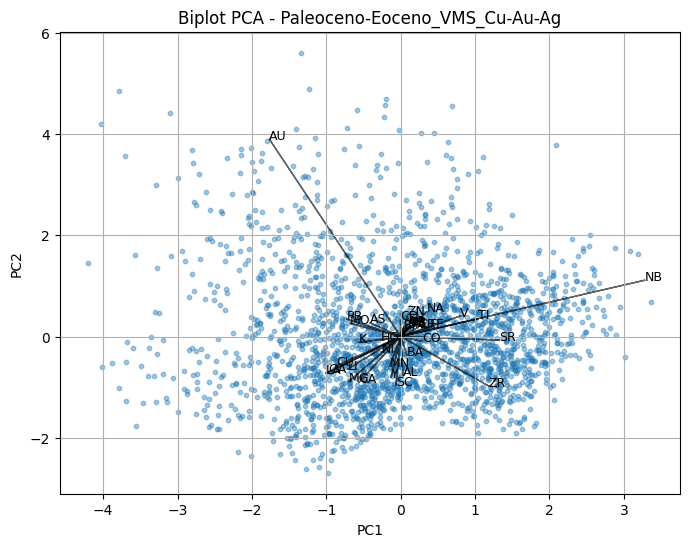

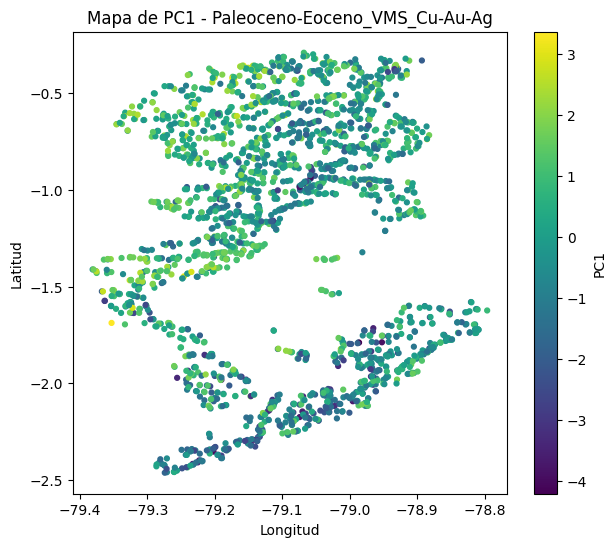

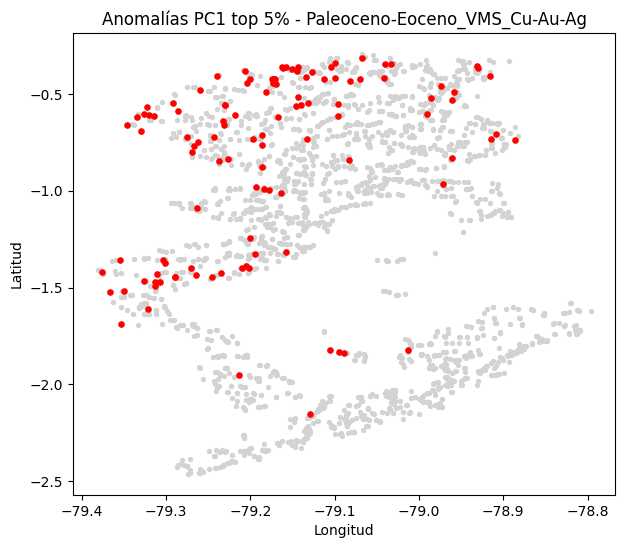

In [ ]:
for faja_elegida in fajas_restantes:

    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja_elegida,
        geo_cols_clean,
        faja_col
    )

    # Varianza explicada
    explained = pca_faja.explained_variance_ratio_

    plt.figure(figsize=(7,5))
    plt.plot(np.cumsum(explained), marker='o')
    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza acumulada")
    plt.title(f"Varianza explicada acumulada - {faja_elegida}")
    plt.grid()
    plt.show()

    # Biplot
    loadings = pd.DataFrame(
        pca_faja.components_.T,
        columns=[f"PC{i+1}" for i in range(len(geo_clr_faja_df.columns))],
        index=geo_clr_faja_df.columns
    )

    plt.figure(figsize=(8,6))

    plt.scatter(
        pca_result_faja[:, 0],
        pca_result_faja[:, 1],
        alpha=0.4,
        s=10
    )

    scale = 5

    for i, var in enumerate(loadings.index):
        plt.arrow(
            0, 0,
            loadings.iloc[i, 0] * scale,
            loadings.iloc[i, 1] * scale,
            alpha=0.6
        )
        plt.text(
            loadings.iloc[i, 0] * scale,
            loadings.iloc[i, 1] * scale,
            var,
            fontsize=9
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Biplot PCA - {faja_elegida}")
    plt.grid()
    plt.show()

    # Mapa PC1
    df_faja["PC1"] = pca_result_faja[:, 0]

    plt.figure(figsize=(7,6))

    sc = plt.scatter(
        df_faja["lon_wgs84"],
        df_faja["lat_wgs84"],
        c=df_faja["PC1"],
        s=12
    )

    plt.colorbar(sc, label="PC1")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.title(f"Mapa de PC1 - {faja_elegida}")
    plt.show()

    # Anomalías PC1 top 5%
    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    plt.figure(figsize=(7,6))

    plt.scatter(
        df_faja["lon_wgs84"],
        df_faja["lat_wgs84"],
        color="lightgray",
        s=8
    )

    plt.scatter(
        df_faja[df_faja["PC1_anom"]]["lon_wgs84"],
        df_faja[df_faja["PC1_anom"]]["lat_wgs84"],
        color="red",
        s=14
    )

    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.title(f"Anomalías PC1 top 5% - {faja_elegida}")
    plt.show()

In [ ]:
#Resumen de los resultados obtenidos
resultados_finales = []

for faja in df[faja_col].unique():

    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja,
        geo_cols_clean,
        faja_col
    )

    # Agregar componentes principales
    df_faja = df_faja.copy()
    df_faja["PC1"] = pca_result_faja[:, 0]
    df_faja["PC2"] = pca_result_faja[:, 1]

    # Anomalías
    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    # Guardar solo columnas clave
    columnas_exportar = [
        "MSLINK",
        "lon_wgs84",
        "lat_wgs84",
        faja_col,
        "PC1",
        "PC2",
        "PC1_anom"
    ]

    resultados_finales.append(df_faja[columnas_exportar])

# Unir todo
df_final = pd.concat(resultados_finales)

# Exportar
df_final.to_csv("resultados_geoquimica_por_faja.csv", index=False)

===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]
===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]


In [ ]:
#Exportar PC1 para visualizarlo junto con el mapa de fajas metalogénicas en software GIS
from google.colab import files
files.download("resultados_geoquimica_por_faja.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


FAJA: Cretacico_VMS_Cu-Au-Ag
===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
Distribución de clases:
PC1_anom
False    2345
True      124
Name: count, dtype: int64

-------------------------------
Modelo: No balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.97      1.00      0.98       469
        True       0.85      0.44      0.58        25

    accuracy                           0.97       494
   macro avg       0.91      0.72      0.78       494
weighted avg       0.96      0.97      0.96       494

Importancia de variables:
AS    0.284734
PB    0.199649
AU    0.167958
SB    0.092344
ZN    0.061028
CU    0.054492
MO    0.053530
HG    0.045785
AG    0.040480
dtype: float64


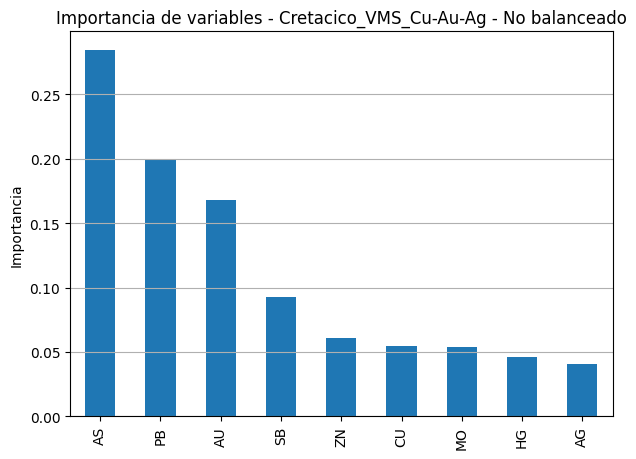


-------------------------------
Modelo: Balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       469
        True       0.77      0.40      0.53        25

    accuracy                           0.96       494
   macro avg       0.87      0.70      0.75       494
weighted avg       0.96      0.96      0.96       494

Importancia de variables:
AS    0.363309
PB    0.233534
AU    0.171543
SB    0.066615
ZN    0.054173
HG    0.038200
MO    0.031848
CU    0.025349
AG    0.015430
dtype: float64


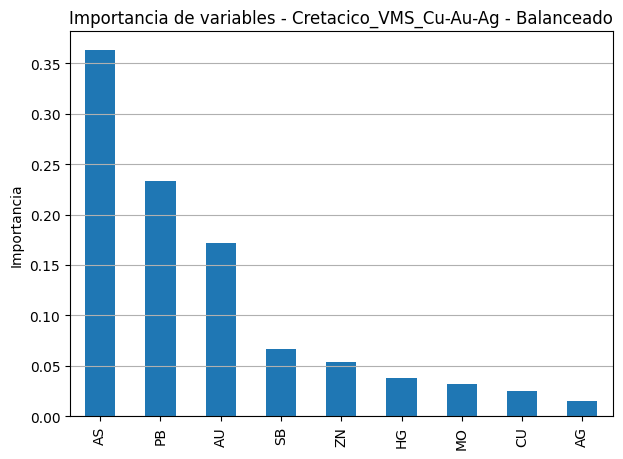


FAJA: Mioceno_Porfidos-Cu-Mo-Au
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
Distribución de clases:
PC1_anom
False    2915
True      154
Name: count, dtype: int64

-------------------------------
Modelo: No balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.97      1.00      0.98       583
        True       0.93      0.45      0.61        31

    accuracy                           0.97       614
   macro avg       0.95      0.72      0.80       614
weighted avg       0.97      0.97      0.97       614

Importancia de variables:
AS    0.173052
PB    0.162499
SB    0.158526
AU    0.157372
ZN    0.089071
MO    0.088140
AG    0.074997
HG    0.052082
CU    0.044261
dtype: float64


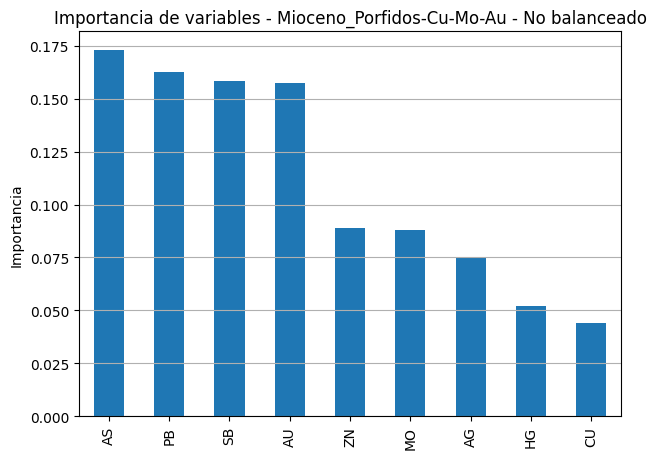


-------------------------------
Modelo: Balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.97      1.00      0.98       583
        True       0.92      0.39      0.55        31

    accuracy                           0.97       614
   macro avg       0.95      0.69      0.76       614
weighted avg       0.97      0.97      0.96       614

Importancia de variables:
PB    0.281695
AS    0.279684
AU    0.158372
SB    0.115822
MO    0.061464
HG    0.035434
ZN    0.028489
CU    0.019766
AG    0.019275
dtype: float64


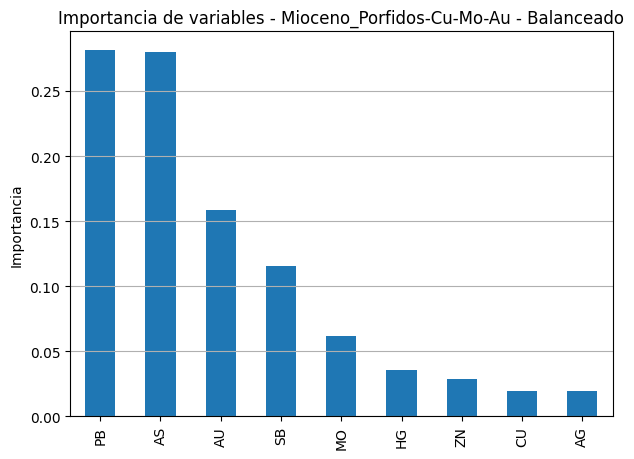


FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu
===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]
Distribución de clases:
PC1_anom
False    5113
True      270
Name: count, dtype: int64

-------------------------------
Modelo: No balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.98      0.99      0.98      1023
        True       0.81      0.56      0.66        54

    accuracy                           0.97      1077
   macro avg       0.89      0.77      0.82      1077
weighted avg       0.97      0.97      0.97      1077

Importancia de variables:
AS    0.216381
PB    0.146407
MO    0.119018
AG    0.108182
HG    0.101263
SB    0.085641
AU    0.083638
ZN    0.071693
CU    0.067775
dtype: float64


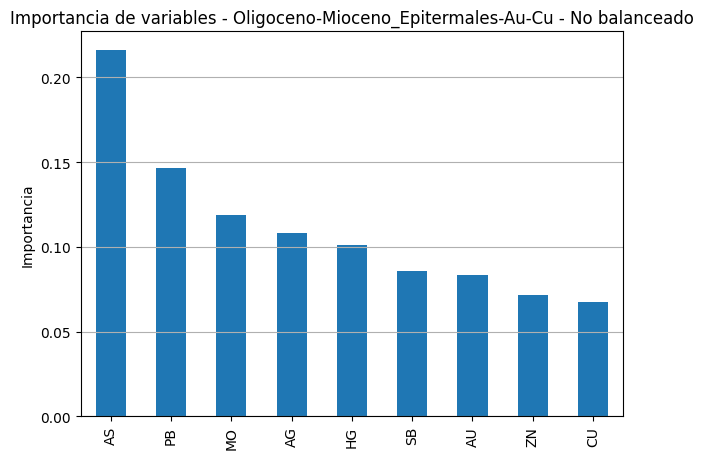


-------------------------------
Modelo: Balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.97      0.99      0.98      1023
        True       0.69      0.37      0.48        54

    accuracy                           0.96      1077
   macro avg       0.83      0.68      0.73      1077
weighted avg       0.95      0.96      0.95      1077

Importancia de variables:
AS    0.339086
PB    0.214664
HG    0.103151
MO    0.101950
SB    0.089752
AU    0.045128
AG    0.041412
ZN    0.033285
CU    0.031572
dtype: float64


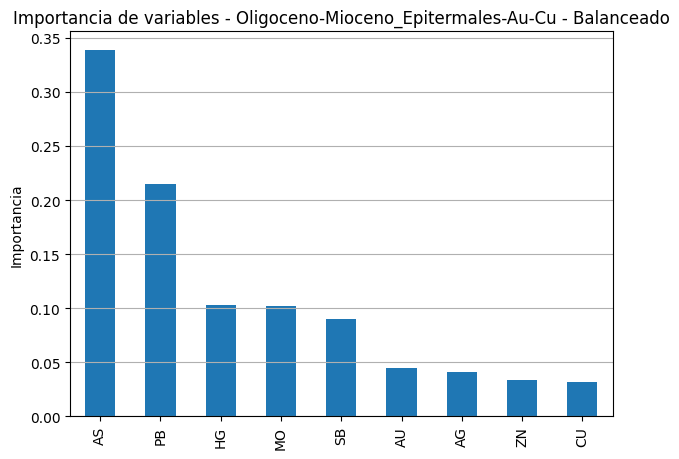


FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag
===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]
Distribución de clases:
PC1_anom
False    2120
True      112
Name: count, dtype: int64

-------------------------------
Modelo: No balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.96      0.99      0.98       425
        True       0.67      0.27      0.39        22

    accuracy                           0.96       447
   macro avg       0.82      0.63      0.68       447
weighted avg       0.95      0.96      0.95       447

Importancia de variables:
CU    0.181997
ZN    0.156933
AU    0.125857
MO    0.125427
PB    0.115577
AG    0.084552
AS    0.074572
SB    0.068893
HG    0.066191
dtype: float64


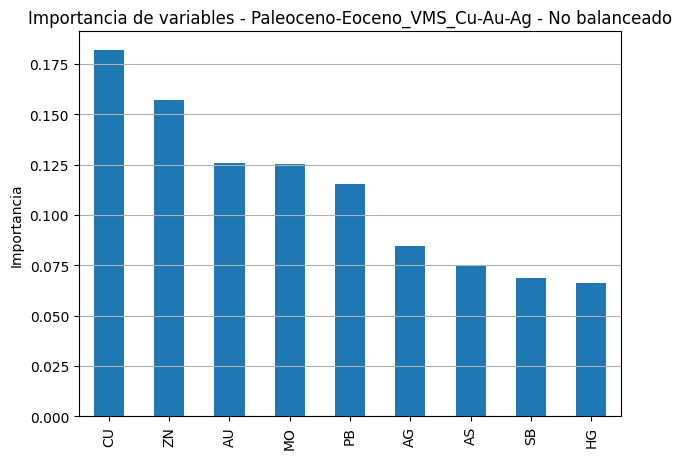


-------------------------------
Modelo: Balanceado
-------------------------------
              precision    recall  f1-score   support

       False       0.96      1.00      0.98       425
        True       0.86      0.27      0.41        22

    accuracy                           0.96       447
   macro avg       0.91      0.64      0.70       447
weighted avg       0.96      0.96      0.95       447

Importancia de variables:
CU    0.259791
AU    0.196062
ZN    0.139384
PB    0.094799
MO    0.087777
AS    0.070469
HG    0.053454
AG    0.049779
SB    0.048485
dtype: float64


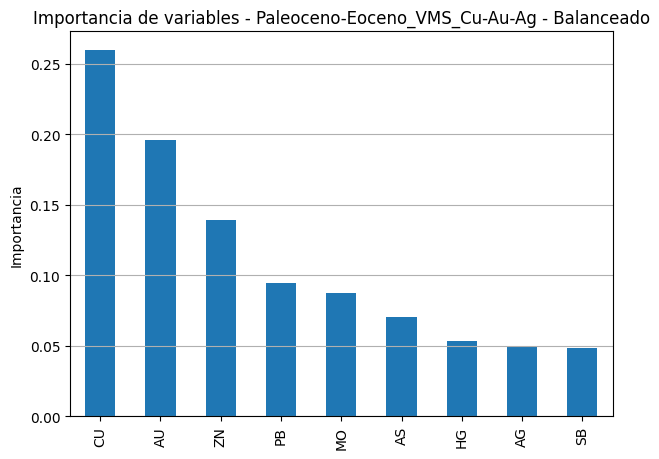


RESUMEN COMPARATIVO BALANCEADO VS NO BALANCEADO


,Faja,Modelo,Accuracy,Precision_True,Recall_True,F1_True,Support_True,Precision_False,Recall_False,F1_False
0,Cretacico_VMS_Cu-Au-Ag,No balanceado,0.967611,0.846154,0.440000,0.578947,25.0,0.970894,0.995736,0.983158
1,Cretacico_VMS_Cu-Au-Ag,Balanceado,0.963563,0.769231,0.400000,0.526316,25.0,0.968815,0.993603,0.981053
2,Mioceno_Porfidos-Cu-Mo-Au,No balanceado,0.970684,0.933333,0.451613,0.608696,31.0,0.971619,0.998285,0.984772
3,Mioceno_Porfidos-Cu-Mo-Au,Balanceado,0.967427,0.923077,0.387097,0.545455,31.0,0.968386,0.998285,0.983108
4,Oligoceno-Mioceno_Epitermales-Au-Cu,No balanceado,0.971216,0.810811,0.555556,0.659341,54.0,0.976923,0.993157,0.984973
5,Oligoceno-Mioceno_Epitermales-Au-Cu,Balanceado,0.960074,0.689655,0.370370,0.481928,54.0,0.967557,0.991202,0.979237
6,Paleoceno-Eoceno_VMS_Cu-Au-Ag,No balanceado,0.957494,0.666667,0.272727,0.387097,22.0,0.963470,0.992941,0.977984
7,Paleoceno-Eoceno_VMS_Cu-Au-Ag,Balanceado,0.961969,0.857143,0.272727,0.413793,22.0,0.963636,0.997647,0.980347


In [ ]:
#Entrenamiento de Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Suite mineralizante amplia
geo_cols_mineral = ["AU", "CU", "PB", "ZN", "AS", "SB", "HG", "MO", "AG"]

fajas_rf = [
    "Cretacico_VMS_Cu-Au-Ag",
    "Mioceno_Porfidos-Cu-Mo-Au",
    "Oligoceno-Mioceno_Epitermales-Au-Cu",
    "Paleoceno-Eoceno_VMS_Cu-Au-Ag"
]

resumen_modelos = []
importancias_modelos = {}

for faja_elegida in fajas_rf:

    print("\n====================================================")
    print(f"FAJA: {faja_elegida}")
    print("====================================================")

    # PCA por faja
    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja_elegida,
        geo_cols_clean,
        faja_col
    )

    # Crear target de anomalía
    df_faja = df_faja.copy()
    df_faja["PC1"] = pca_result_faja[:, 0]

    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    # Variables mineralizantes disponibles
    geo_cols_mineral_faja = [
        col for col in geo_cols_mineral
        if col in geo_clr_faja_df.columns
    ]

    X = geo_clr_faja_df[geo_cols_mineral_faja]
    y = df_faja["PC1_anom"]

    print("Distribución de clases:")
    print(y.value_counts())

    # División estratificada
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    modelos = {
        "No balanceado": RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),
        "Balanceado": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42
        )
    }

    for nombre_modelo, modelo in modelos.items():

        print("\n-------------------------------")
        print(f"Modelo: {nombre_modelo}")
        print("-------------------------------")

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        print(classification_report(y_test, y_pred))

        report = classification_report(y_test, y_pred, output_dict=True)

        resumen_modelos.append({
            "Faja": faja_elegida,
            "Modelo": nombre_modelo,
            "Accuracy": report["accuracy"],
            "Precision_True": report["True"]["precision"],
            "Recall_True": report["True"]["recall"],
            "F1_True": report["True"]["f1-score"],
            "Support_True": report["True"]["support"],
            "Precision_False": report["False"]["precision"],
            "Recall_False": report["False"]["recall"],
            "F1_False": report["False"]["f1-score"]
        })

        importancias = pd.Series(
            modelo.feature_importances_,
            index=X.columns
        ).sort_values(ascending=False)

        importancias_modelos[(faja_elegida, nombre_modelo)] = importancias

        print("Importancia de variables:")
        print(importancias)

        plt.figure(figsize=(7,5))
        importancias.plot(kind="bar")
        plt.title(f"Importancia de variables - {faja_elegida} - {nombre_modelo}")
        plt.ylabel("Importancia")
        plt.grid(axis="y")
        plt.show()

# Tabla resumen final
df_comparacion_modelos = pd.DataFrame(resumen_modelos)

print("\n====================================================")
print("RESUMEN COMPARATIVO BALANCEADO VS NO BALANCEADO")
print("====================================================")

display(df_comparacion_modelos)



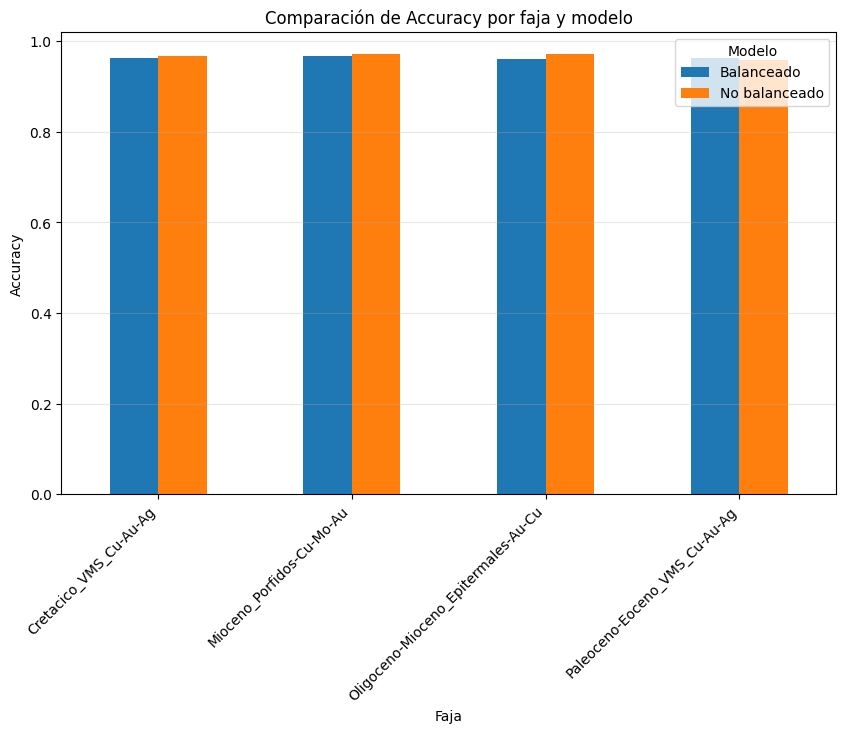

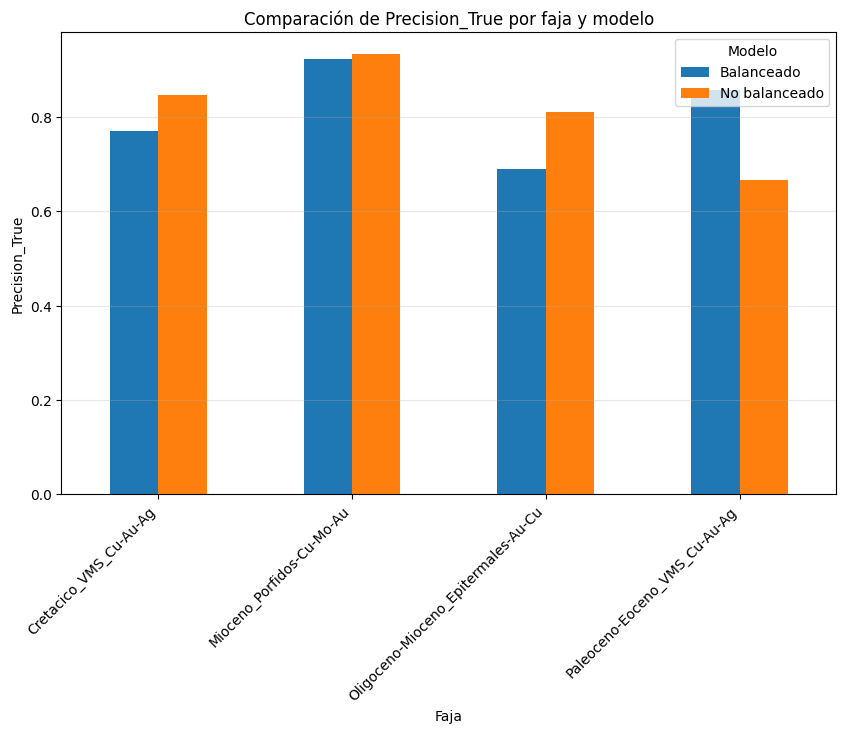

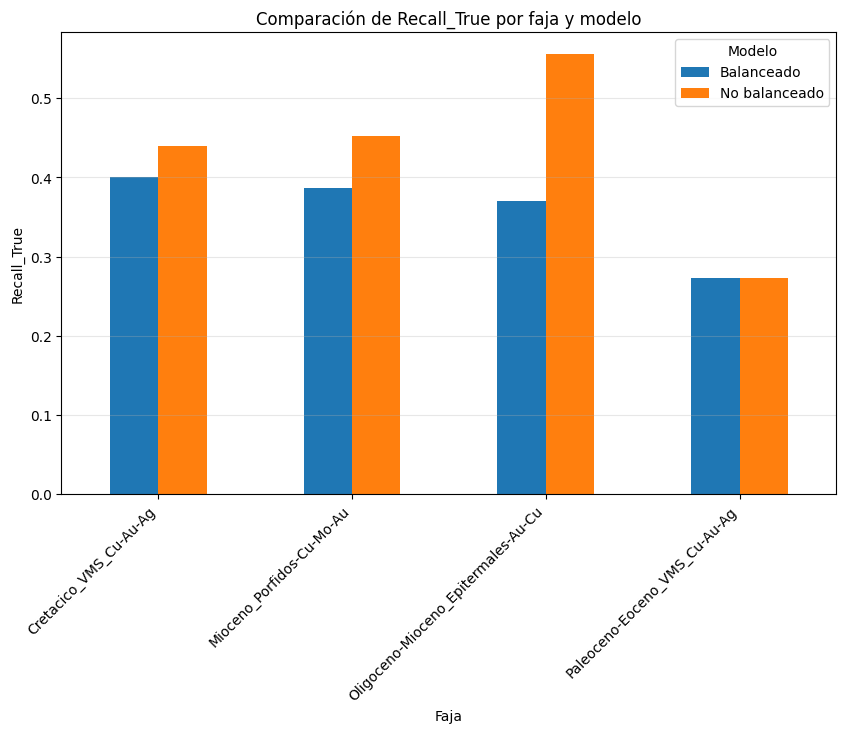

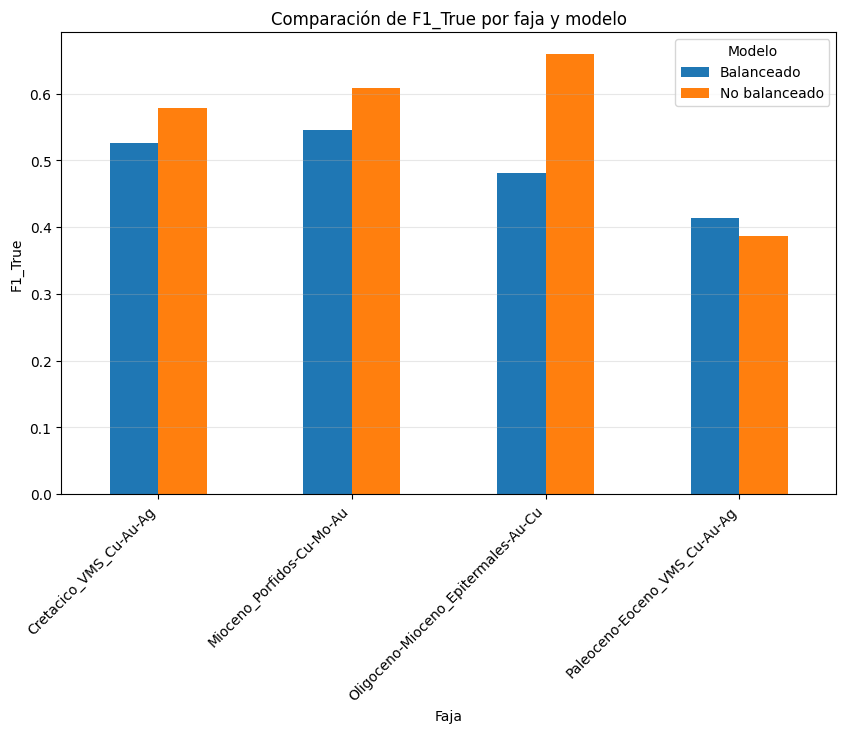

In [ ]:
metricas = ["Accuracy", "Precision_True", "Recall_True", "F1_True"]

for metrica in metricas:
    tabla = df_comparacion_modelos.pivot(
        index="Faja",
        columns="Modelo",
        values=metrica
    )

    tabla.plot(kind="bar", figsize=(10,6))
    plt.ylabel(metrica)
    plt.title(f"Comparación de {metrica} por faja y modelo")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Modelo")
    plt.show()


Random Forest con TODOS los elementos - Cretacico_VMS_Cu-Au-Ag
===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
              precision    recall  f1-score   support

       False       0.96      0.99      0.98       469
        True       0.70      0.28      0.40        25

    accuracy                           0.96       494
   macro avg       0.83      0.64      0.69       494
weighted avg       0.95      0.96      0.95       494

AS    0.185082
AU    0.124246
PB    0.111449
TI    0.099954
NB    0.081514
ZR    0.063012
V     0.046040
LA    0.026813
SB    0.020864
FE    0.019307
SC    0.019164
CO    0.018275
K     0.017825
AL    0.016184
ZN    0.014416
dtype: float64


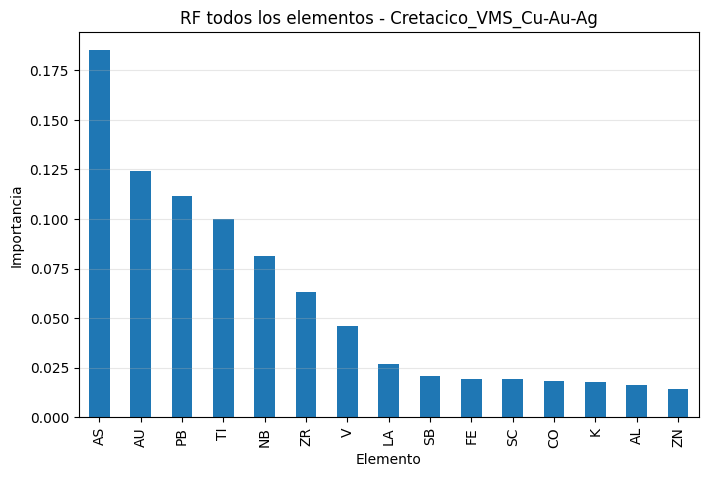


Random Forest con TODOS los elementos - Mioceno_Porfidos-Cu-Mo-Au
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
              precision    recall  f1-score   support

       False       0.97      1.00      0.98       583
        True       0.93      0.45      0.61        31

    accuracy                           0.97       614
   macro avg       0.95      0.72      0.80       614
weighted avg       0.97      0.97      0.97       614

AS    0.158729
PB    0.148114
AU    0.109792
TI    0.093605
SR    0.069565
V     0.068103
SB    0.065453
NB    0.049568
MO    0.028105
ZR    0.018959
FE    0.017510
SC    0.014027
NA    0.011985
CD    0.011803
HG    0.011398
dtype: float64


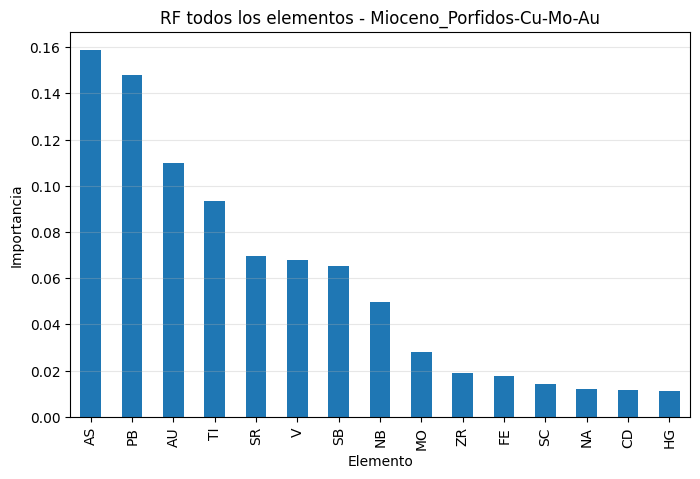


Random Forest con TODOS los elementos - Oligoceno-Mioceno_Epitermales-Au-Cu
===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]
              precision    recall  f1-score   support

       False       0.98      1.00      0.99      1023
        True       0.90      0.65      0.75        54

    accuracy                           0.98      1077
   macro avg       0.94      0.82      0.87      1077
weighted avg       0.98      0.98      0.98      1077

TI    0.177654
AS    0.126601
V     0.120004
CR    0.080927
ZR    0.067706
PB    0.060307
NA    0.044413
SR    0.042117
SB    0.034803
HG    0.026477
NI    0.023903
MO    0.021383
LA    0.019117
CD    0.017424
NB    0.011386
dtype: float64


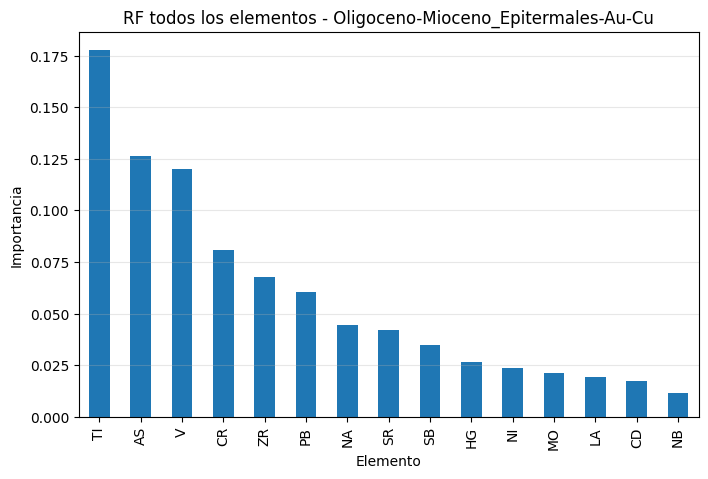


Random Forest con TODOS los elementos - Paleoceno-Eoceno_VMS_Cu-Au-Ag
===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]
              precision    recall  f1-score   support

       False       0.97      1.00      0.99       425
        True       0.92      0.50      0.65        22

    accuracy                           0.97       447
   macro avg       0.95      0.75      0.82       447
weighted avg       0.97      0.97      0.97       447

NB    0.259584
TI    0.103515
V     0.087755
MG    0.061019
LI    0.059818
CO    0.048252
AU    0.047595
FE    0.043483
GA    0.036877
CU    0.033205
CA    0.028005
ZR    0.026765
K     0.022423
CR    0.012729
NI    0.011276
dtype: float64


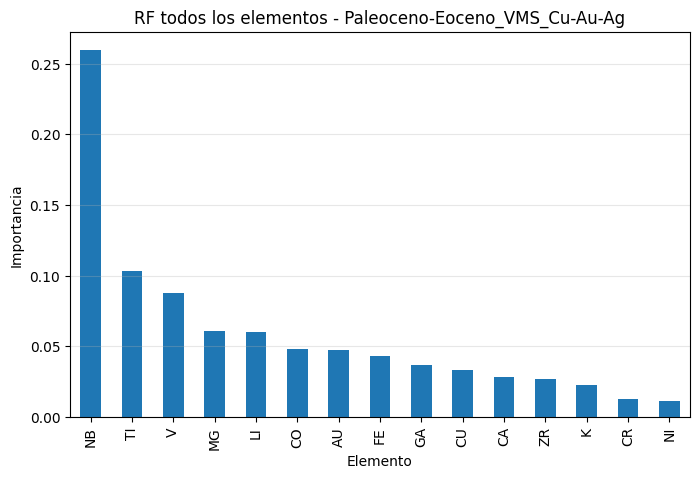

In [ ]:
#resultados_rf_todos
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Diccionario independiente para guardar resultados
resultados_rf_todos = {}

for faja_elegida in df[faja_col].unique():

    print("\n====================================")
    print(f"Random Forest con TODOS los elementos - {faja_elegida}")
    print("====================================")

    # Ejecutar PCA por faja
    df_faja_all, geo_clr_faja_all_df, pca_faja_all, pca_result_faja_all = analizar_pca_por_faja(
        df,
        faja_elegida,
        geo_cols_clean,
        faja_col
    )

    # Crear copia para no modificar análisis previos
    df_faja_all = df_faja_all.copy()

    # Agregar PC1
    df_faja_all["PC1"] = pca_result_faja_all[:, 0]

    # Definir anomalías como top 5% de PC1
    threshold = df_faja_all["PC1"].quantile(0.95)
    df_faja_all["PC1_anom"] = df_faja_all["PC1"] > threshold

    # Variables predictoras: TODOS los elementos transformados con CLR
    X_all = geo_clr_faja_all_df.copy()
    y_all = df_faja_all["PC1_anom"]

    # División entrenamiento/prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all
    )

    # Modelo RF balanceado
    rf_all = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )

    rf_all.fit(X_train, y_train)

    # Predicción
    y_pred = rf_all.predict(X_test)

    # Reporte
    reporte = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))

    # Importancia de variables
    importancias_all = pd.Series(
        rf_all.feature_importances_,
        index=X_all.columns
    ).sort_values(ascending=False)

    print(importancias_all.head(15))

    # Guardar resultados sin afectar análisis anteriores
    resultados_rf_todos[faja_elegida] = {
        "df_faja": df_faja_all,
        "geo_clr": geo_clr_faja_all_df,
        "pca": pca_faja_all,
        "pca_result": pca_result_faja_all,
        "modelo_rf": rf_all,
        "importancias": importancias_all,
        "reporte": reporte
    }

    # Gráfico top 15 variables
    plt.figure(figsize=(8,5))
    importancias_all.head(15).plot(kind="bar")
    plt.title(f"RF todos los elementos - {faja_elegida}")
    plt.ylabel("Importancia")
    plt.xlabel("Elemento")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Faja a evaluar
faja_elegida = "Oligoceno-Mioceno_Epitermales-Au-Cu"

# Elementos mineralizantes
geo_cols_mineral = ["AU", "CU", "PB", "ZN", "AS", "SB", "HG", "MO", "AG"]

# Ejecutar PCA por faja
df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
    df,
    faja_elegida,
    geo_cols_clean,
    faja_col
)

# Crear PC1 y anomalías
df_faja = df_faja.copy()
df_faja["PC1"] = pca_result_faja[:, 0]

threshold = df_faja["PC1"].quantile(0.95)
df_faja["PC1_anom"] = df_faja["PC1"] > threshold

# Usar solo elementos mineralizantes disponibles
geo_cols_mineral_faja = [
    col for col in geo_cols_mineral
    if col in geo_clr_faja_df.columns
]

X = geo_clr_faja_df[geo_cols_mineral_faja]
y = df_faja["PC1_anom"]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]


In [ ]:
n_arboles = [50, 100, 200, 300, 500]

resultados_sensibilidad = []

for n in n_arboles:

    rf = RandomForestClassifier(
        n_estimators=n,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    resultados_sensibilidad.append({
        "n_estimators": n,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_anomalia": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall_anomalia": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1_anomalia": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    })

tabla_sensibilidad = pd.DataFrame(resultados_sensibilidad)

tabla_sensibilidad

,n_estimators,accuracy,precision_anomalia,recall_anomalia,f1_anomalia
0,50,0.960074,0.677419,0.388889,0.494118
1,100,0.959146,0.678571,0.351852,0.463415
2,200,0.959146,0.678571,0.351852,0.463415
3,300,0.960074,0.689655,0.370370,0.481928
4,500,0.959146,0.666667,0.370370,0.476190


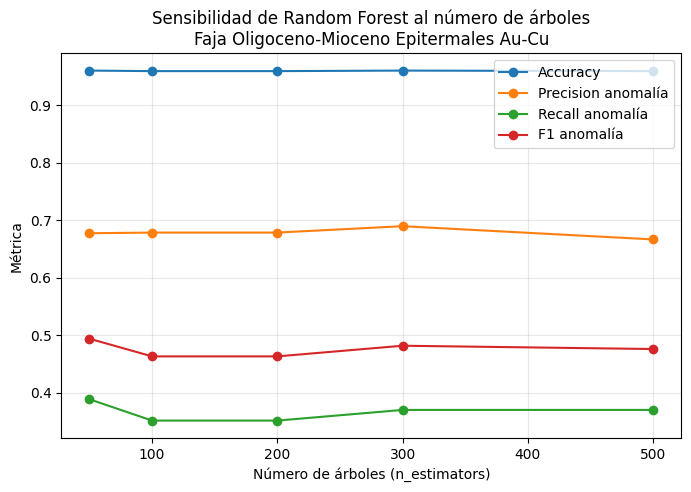

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["precision_anomalia"],
    marker="o",
    label="Precision anomalía"
)

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["recall_anomalia"],
    marker="o",
    label="Recall anomalía"
)

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["f1_anomalia"],
    marker="o",
    label="F1 anomalía"
)

plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Métrica")
plt.title("Sensibilidad de Random Forest al número de árboles\nFaja Oligoceno-Mioceno Epitermales Au-Cu")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

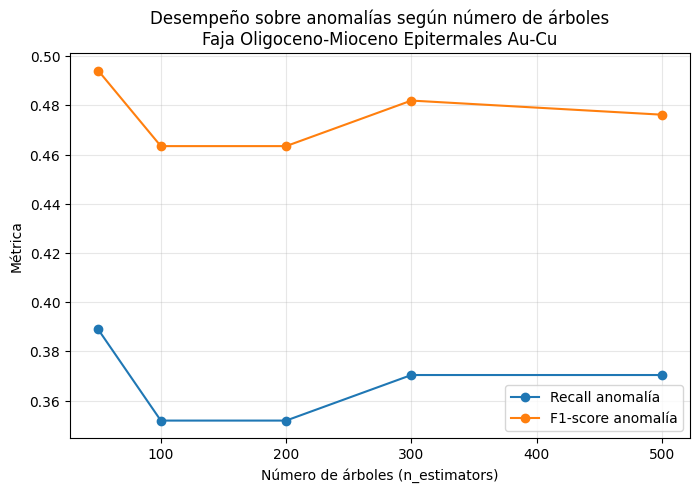

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["recall_anomalia"],
    marker="o",
    label="Recall anomalía"
)

plt.plot(
    tabla_sensibilidad["n_estimators"],
    tabla_sensibilidad["f1_anomalia"],
    marker="o",
    label="F1-score anomalía"
)

plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Métrica")
plt.title("Desempeño sobre anomalías según número de árboles\nFaja Oligoceno-Mioceno Epitermales Au-Cu")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# tabla global con PC1_anom por faja
resultados_clases = []

for faja in df[faja_col].unique():

    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja,
        geo_cols_clean,
        faja_col
    )

    df_faja = df_faja.copy()
    df_faja["PC1"] = pca_result_faja[:, 0]

    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    resultados_clases.append(
        df_faja[[faja_col, "PC1", "PC1_anom"]]
    )

df_clases = pd.concat(resultados_clases, ignore_index=True)

df_clases.head()

===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]
===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]


,Fajas,PC1,PC1_anom
0,Cretacico_VMS_Cu-Au-Ag,-1.043735,False
1,Cretacico_VMS_Cu-Au-Ag,-2.894167,False
2,Cretacico_VMS_Cu-Au-Ag,-2.198950,False
3,Cretacico_VMS_Cu-Au-Ag,-1.846144,False
4,Cretacico_VMS_Cu-Au-Ag,-0.892618,False


In [ ]:
#Tabla de clases desbalanceadas por faja
tabla_clases = pd.crosstab(
    df_clases[faja_col],
    df_clases["PC1_anom"]
)

tabla_clases.columns = ["No_anomalia", "Anomalia"]

tabla_clases


,No_anomalia,Anomalia
Fajas,,
Cretacico_VMS_Cu-Au-Ag,2345,124
Mioceno_Porfidos-Cu-Mo-Au,2915,154
Oligoceno-Mioceno_Epitermales-Au-Cu,5113,270
Paleoceno-Eoceno_VMS_Cu-Au-Ag,2120,112


In [ ]:
#Tabla en porcentaje
tabla_clases_pct = tabla_clases.div(tabla_clases.sum(axis=1), axis=0) * 100

tabla_clases_pct

,No_anomalia,Anomalia
Fajas,,
Cretacico_VMS_Cu-Au-Ag,94.977724,5.022276
Mioceno_Porfidos-Cu-Mo-Au,94.982079,5.017921
Oligoceno-Mioceno_Epitermales-Au-Cu,94.984210,5.015790
Paleoceno-Eoceno_VMS_Cu-Au-Ag,94.982079,5.017921


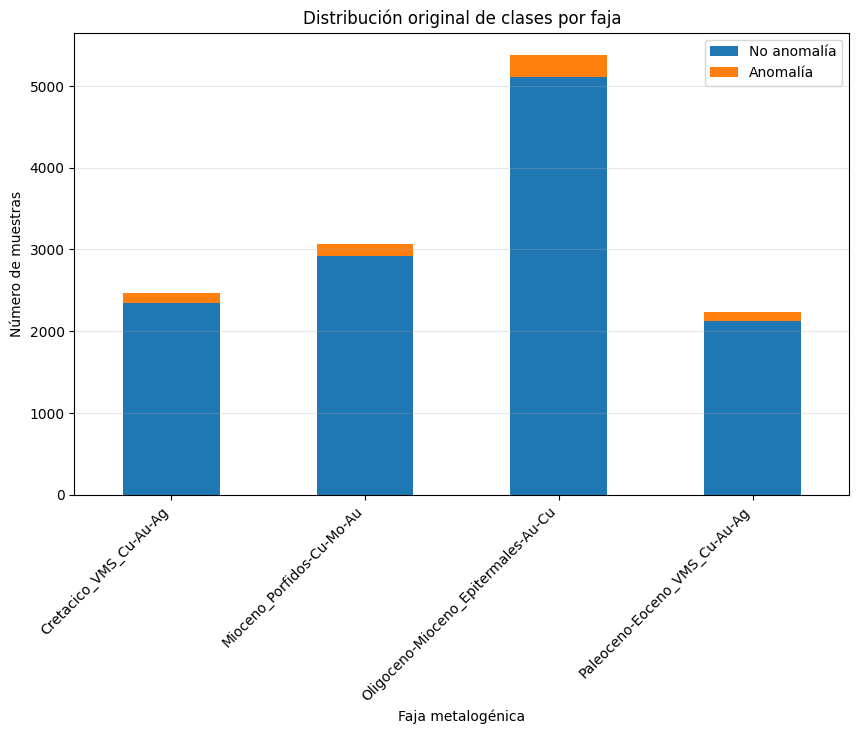

In [ ]:
import matplotlib.pyplot as plt

tabla_clases.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xlabel("Faja metalogénica")
plt.ylabel("Número de muestras")
plt.title("Distribución original de clases por faja")
plt.legend(["No anomalía", "Anomalía"])
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Elementos mineralizantes
geo_cols_mineral = ["AU", "CU", "PB", "ZN", "AS", "SB", "HG", "MO", "AG"]

# Guardar resultados
resultados_auc_mineral = []

for faja_elegida in df[faja_col].unique():

    print("\n====================================")
    print(f"AUC Random Forest - {faja_elegida}")
    print("====================================")

    # PCA por faja
    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja_elegida,
        geo_cols_clean,
        faja_col
    )

    # Crear PC1 y anomalías
    df_faja = df_faja.copy()
    df_faja["PC1"] = pca_result_faja[:, 0]

    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    # Seleccionar elementos mineralizantes disponibles
    geo_cols_mineral_faja = [
        col for col in geo_cols_mineral
        if col in geo_clr_faja_df.columns
    ]

    X = geo_clr_faja_df[geo_cols_mineral_faja]
    y = df_faja["PC1_anom"]

    # División entrenamiento/prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Modelo Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)

    # Predicción de clases
    y_pred = rf.predict(X_test)

    # Probabilidad de clase positiva: anomalía=True
    y_prob = rf.predict_proba(X_test)[:, 1]

    # AUC
    auc = roc_auc_score(y_test, y_prob)

    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {auc:.4f}")

    resultados_auc_mineral.append({
        "Faja": faja_elegida,
        "AUC_ROC": auc
    })

# Tabla final
tabla_auc_mineral = pd.DataFrame(resultados_auc_mineral)

tabla_auc_mineral


AUC Random Forest - Cretacico_VMS_Cu-Au-Ag
===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       469
        True       0.77      0.40      0.53        25

    accuracy                           0.96       494
   macro avg       0.87      0.70      0.75       494
weighted avg       0.96      0.96      0.96       494

AUC-ROC: 0.9787

AUC Random Forest - Mioceno_Porfidos-Cu-Mo-Au
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
              precision    recall  f1-score   support

       False       0.97      1.00      0.98       583
        True       0.92      0.39   

,Faja,AUC_ROC
0,Cretacico_VMS_Cu-Au-Ag,0.978678
1,Mioceno_Porfidos-Cu-Mo-Au,0.985116
2,Oligoceno-Mioceno_Epitermales-Au-Cu,0.982043
3,Paleoceno-Eoceno_VMS_Cu-Au-Ag,0.863102


===== FAJA: Cretacico_VMS_Cu-Au-Ag =====
Número de muestras: 2469
Varianza explicada acumulada:
[0.21678017 0.34816869 0.47462185 0.56500197 0.63212856 0.69044159
 0.74209252 0.7783878  0.80718998 0.83302972]
===== FAJA: Mioceno_Porfidos-Cu-Mo-Au =====
Número de muestras: 3069
Varianza explicada acumulada:
[0.23924379 0.36325176 0.45176915 0.53382311 0.60335694 0.65443712
 0.70002196 0.73961778 0.77132132 0.79805611]
===== FAJA: Oligoceno-Mioceno_Epitermales-Au-Cu =====
Número de muestras: 5383
Varianza explicada acumulada:
[0.2951103  0.4202515  0.50393793 0.57599434 0.63596891 0.68195883
 0.72166911 0.75580496 0.78496028 0.8132731 ]
===== FAJA: Paleoceno-Eoceno_VMS_Cu-Au-Ag =====
Número de muestras: 2232
Varianza explicada acumulada:
[0.14731756 0.27457621 0.38574526 0.49141598 0.57585981 0.6370395
 0.68456455 0.72722664 0.76454972 0.79927615]


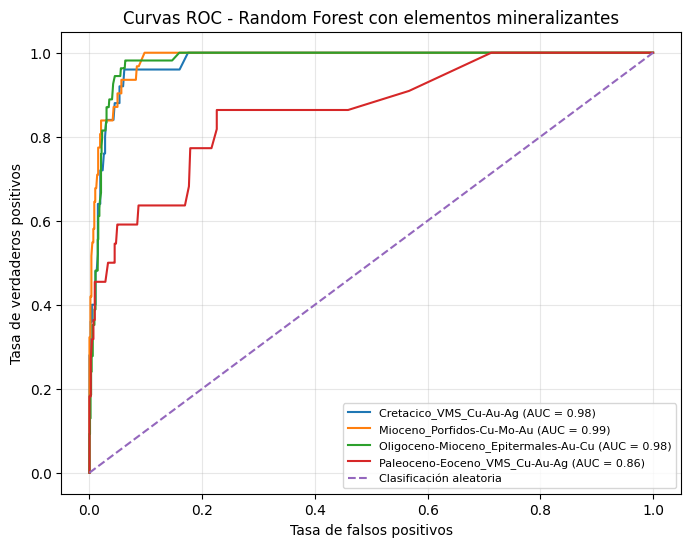

In [ ]:
#Analisis AUC
plt.figure(figsize=(8, 6))

for faja_elegida in df[faja_col].unique():

    # PCA por faja
    df_faja, geo_clr_faja_df, pca_faja, pca_result_faja = analizar_pca_por_faja(
        df,
        faja_elegida,
        geo_cols_clean,
        faja_col
    )

    df_faja = df_faja.copy()
    df_faja["PC1"] = pca_result_faja[:, 0]

    threshold = df_faja["PC1"].quantile(0.95)
    df_faja["PC1_anom"] = df_faja["PC1"] > threshold

    geo_cols_mineral_faja = [
        col for col in geo_cols_mineral
        if col in geo_clr_faja_df.columns
    ]

    X = geo_clr_faja_df[geo_cols_mineral_faja]
    y = df_faja["PC1_anom"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_prob = rf.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{faja_elegida} (AUC = {auc:.2f})")

# Línea aleatoria
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - Random Forest con elementos mineralizantes")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()